In [1]:
#数据导入及处理缺失值
#Data import and handling of missing values
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

# 加载数据
data = fetch_california_housing()

X = data.data          # 特征矩阵
y = data.target        # 目标值（房价）

feature_names = data.feature_names

# 转为 DataFrame（推荐，方便后续操作）
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name="MedHouseVal")

print(X.head())
print(y.head())
print("Shape of X:", X.shape)

# ===== 处理缺失值 =====
print("Missing values before cleaning:")
print(X.isnull().sum())

# 删除含缺失值的行（如果有）
X = X.dropna()
y = y.loc[X.index]   # 保持 X 和 y 对齐

print("Shape after removing missing values:", X.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64
Shape of X: (20640, 8)
Missing values before cleaning:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Shape after removing missing values: (20640, 8)


In [2]:
#Baseline Modal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# 先分出 test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=26
)
#X_train_val → 80% 的特征，X_test → 20% 的特征，y_train_val → 80% 的标签，y_test → 20% 的标签

# 从X_train_val, y_train_val里再分 validation（分成X_train, X_val, y_train, y_val）
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=26
)#这里的0.1是80%里的10%


# 在标准化前，先保存 raw（未标准化）版本：后面kNN需要用原始经纬度
X_train_raw = X_train.copy()
X_val_raw   = X_val.copy()
X_test_raw  = X_test.copy()

# scale (fit only on train)#标准化（只在训练集）并转回DataFrame
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns,index=X_train_raw.index)
X_val   = pd.DataFrame(scaler.transform(X_val), columns=X.columns,index=X_val_raw.index)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test_raw.index)
#scaler.transform 标准化 test 数据
#index=X_test_raw.index Pandas 会默认生成新的 0~n 索引
#加了 index=...，这样索引不会乱（对齐 y / 后面 debug 更稳）

Architecture: (32,), Activation: tanh, Test MSE: 0.2901
Architecture: (32,), Activation: relu, Test MSE: 0.2901
Architecture: (32,), Activation: identity, Test MSE: 0.5076
Architecture: (64,), Activation: tanh, Test MSE: 0.2943
Architecture: (64,), Activation: relu, Test MSE: 0.2913
Architecture: (64,), Activation: identity, Test MSE: 0.5105
Architecture: (64, 32), Activation: tanh, Test MSE: 0.2464
Architecture: (64, 32), Activation: relu, Test MSE: 0.2587
Architecture: (64, 32), Activation: identity, Test MSE: 0.5111
Architecture: (128, 64), Activation: tanh, Test MSE: 0.2579
Architecture: (128, 64), Activation: relu, Test MSE: 0.2491
Architecture: (128, 64), Activation: identity, Test MSE: 0.5128
Architecture: (128, 64, 32), Activation: tanh, Test MSE: 0.2867
Architecture: (128, 64, 32), Activation: relu, Test MSE: 0.2676
Architecture: (128, 64, 32), Activation: identity, Test MSE: 0.5164

=== Test MSE Table ===
Activation     identity      relu      tanh
Architecture               

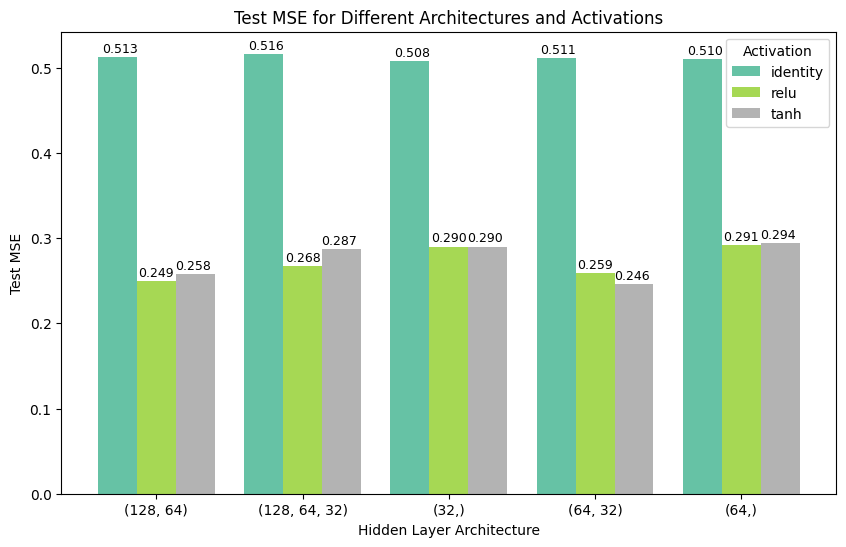

In [5]:
import matplotlib.pyplot as plt
# 1) Define architectures and activation functions
#  定义不同的神经网络结构和激活函数
# ============================================================

# Each tuple represents the number of neurons in hidden layers.
# Example:
# (64,32) means two hidden layers with 64 and 32 neurons.
#
# 每个元组表示隐藏层结构。
# 例如：
# (64,32) 表示两个隐藏层，分别有 64 和 32 个神经元。

architectures = [
    (32,),
    (64,),
    (64,32),
    (128,64),
    (128,64,32)
]

# Activation functions to test.
# tanh  → nonlinear symmetric activation
# relu  → widely used deep learning activation
# identity → linear activation
#
# 要测试的激活函数：
# tanh → 对称的非线性函数
# relu → 深度学习中常用激活函数
# identity → 线性激活函数

activations = ['tanh', 'relu', 'identity']


# ============================================================
# 2) Train models and collect Test MSE
# 训练模型并记录测试集 MSE
# ============================================================

results = []

for arch in architectures:
    for act in activations:

        
        # Create a neural network model with the current architecture
        # and activation function.
        #
        # 创建一个神经网络模型，使用当前的隐藏层结构和激活函数

        model = MLPRegressor(
            hidden_layer_sizes=arch,
            activation=act,
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=700,
            early_stopping=False,
            random_state=26
        )

        
        # Train the model on the training dataset.
        # 在训练集上训练模型

        model.fit(X_train, y_train)

        
        # Predict house prices on the test set.
        
        # 在测试集上进行预测

        test_pred = model.predict(X_test)

        
        # Compute Mean Squared Error (MSE).
        # Lower MSE indicates better prediction performance.
        #
        
        # 计算均方误差（MSE）。
        # MSE 越小，模型预测效果越好。

        test_mse = mean_squared_error(y_test, test_pred)

        results.append({
            'Architecture': str(arch),
            'Activation': act,
            'Test_MSE': test_mse
        })

        print(f"Architecture: {arch}, Activation: {act}, Test MSE: {test_mse:.4f}")


# ============================================================
# 3) Convert results to DataFrame
# 将结果转换为表格
# ============================================================

# 
# Convert the results list into a pandas DataFrame
# and reshape it using pivot for easier visualization.
#

# 将实验结果转换为 DataFrame，
# 再使用 pivot 变成适合绘图的格式。

results_df = pd.DataFrame(results)

pivot_table = results_df.pivot(
    index='Architecture',
    columns='Activation',
    values='Test_MSE'
)

print("\n=== Test MSE Table ===")
print(pivot_table)


# ============================================================
# 4) Plot grouped bar chart
#  绘制分组柱状图
# ============================================================

# Create a grouped bar chart showing Test MSE for each
# architecture and activation combination.
#

# 绘制分组柱状图，
# 展示不同隐藏层结构和激活函数组合的 Test MSE。

ax = pivot_table.plot(
    kind='bar',
    figsize=(10,6),
    width=0.8,
    colormap='Set2'
)

plt.ylabel("Test MSE")
plt.xlabel("Hidden Layer Architecture")
plt.title("Test MSE for Different Architectures and Activations")
plt.xticks(rotation=0)
plt.legend(title="Activation")


# ------------------------------------------------------------
# Add value labels above bars
# 在柱子上显示具体 MSE 数值
# ------------------------------------------------------------

for i, arch in enumerate(pivot_table.index):
    for j, act in enumerate(pivot_table.columns):
        mse = pivot_table.loc[arch, act]

        ax.text(
            i + j*0.25 - 0.25,
            mse + 0.002,
            f"{mse:.3f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.show()

In [7]:
# model (no internal early stopping, since you already have X_val)
model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=700,
    early_stopping=False,
    random_state=26
)

model.fit(X_train, y_train)
#测试集和预测集的预测
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

# 训练集预测
train_pred = model.predict(X_train)
# 计算训练误差
train_mse = mean_squared_error(y_train, train_pred)

print("Baseline Train MSE:", train_mse)#加入是为了判断是不是欠拟合或者过拟合
print("Validation MSE:", mean_squared_error(y_val, val_pred))#Mean Squared Error（均方误差）
print("Test MSE:", mean_squared_error(y_test, test_pred))

Baseline Train MSE: 0.22477832660804273
Validation MSE: 0.28406105550063704
Test MSE: 0.24635235069844585


In [ ]:
# ============================================================
# 第二个模型：加入 neighbourhood feature（NeighbourPrice）
# ============================================================

from sklearn.neighbors import NearestNeighbors  # 用于找k个最近邻

K = 7  # 邻居数量k（你们分支实验可改成3/5/10，但一次实验只改k）找到距离它最近的 7 套房子

# ------------------------------------------------------------
# 1) 用训练集的经纬度建立 kNN（只fit训练集）
#    这样 val/test 找邻居时，也只会在 train 里找（避免用到test标签）
# ------------------------------------------------------------
knn = NearestNeighbors(n_neighbors=K+1)  # 创建kNN搜索器
knn.fit(X_train_raw[['Latitude', 'Longitude']])  # 只用训练集坐标来fit

def neighbour_mean_price(query_df, y_train_series, exclude_self=False):
    """
    为 query_df 的每个样本计算：训练集中k个邻居的 y 的平均值
    query_df: 需要计算邻居特征的数据（train/val/test 的 raw DataFrame）
    y_train_series: 训练集标签（只能用它，避免data leakage）
    exclude_self: 如果 query_df 是训练集本身，要剔除“自己”这个邻居
    """

    #这行代码的作用是把 y_train_series 的顺序重新排列，使它与 X_train_raw 的索引顺序完全一致，从而保证每一行特征对应正确的标签。
    y_train_series = y_train_series.loc[X_train_raw.index]
    #根据每个样本的经纬度，在训练集中找到最近的 K 个邻居，并返回这些邻居的距离 (dists) 和在训练集中的位置索引 (inds)
    dists, inds = knn.kneighbors(query_df[['Latitude', 'Longitude']])

    neigh_mean = [] ## 存放每个样本的邻居均价
    for row_i, idxs in enumerate(inds):
        if exclude_self:
            # 只剔除“自己这一行”的训练索引（最严谨），剔除自己（完全一样的那行数据）
            idxs = idxs[idxs != row_i]  # 用位置索引剔除自己
            idxs = idxs[:K]                 # 保证还是K个邻居，比如上一行代码要执行删除时，原数据并没有自己defensive programming（防御式编程）
            #比如以后用距离过滤，或者过滤多个点，不会变成 6 个或其他奇怪数量
        else:
            # val/test 直接取前K个邻居（它们全来自train）
            idxs = idxs[:K]
        # 用训练集的 y_train 取邻居价格并求平均（关键：不使用val/test真实y）
        neigh_mean.append(y_train_series.iloc[idxs].mean())

    return np.array(neigh_mean)
'''
觉得“我在训练集里拿某一条样本当 query，那 kNN 返回的邻居里怎么可能没有它自己？”
按数学定义，它应该一定在。
但你看到的 Case A（极少数）说明：在实现细节上，它“可能不在返回的前 K+1 个里”。
原因主要是 并列距离（tie）+ 只取前 K+1 个 + 内部取子集。

你并不是“先拿这一条样本再算平均”

你做的是：
用这条样本的经纬度作为 query
让 kneighbors() 在训练集里找 最接近的 n_neighbors 个点
返回这些点的索引
你再用这些索引去取 y_train 求平均

也就是说：
你并不是在邻居列表里手动把“自己”塞进去。
你完全依赖 kneighbors() 返回的那一组邻居
'''
# ------------------------------------------------------------
# 2) 计算 NeighbourPrice（邻居均价）
#    - train：剔除自己
#    - val/test：邻居都来自train，不存在“自己”，不用剔除
# ------------------------------------------------------------
neigh_price_train = neighbour_mean_price(X_train_raw, y_train, exclude_self=True)
neigh_price_val   = neighbour_mean_price(X_val_raw,   y_train, exclude_self=False)
neigh_price_test  = neighbour_mean_price(X_test_raw,  y_train, exclude_self=False)
#exclude_self=True 每个样本最近的点一定是自己，所以删除自己
#验证集样本根本不在训练集中，所以后面不需要删除自己

'''
| 变量          | 作用              |
| ----------- | --------------- |
| `X_val_raw` | 查询点（我想知道它附近房价）  |
| `y_train`   | 数据库（我用它来查邻居的价格） |
'''

# ------------------------------------------------------------
# 3) 把新特征train,val和test 的 neighbour price 加到 raw 数据里，做成新列（注意：从 raw 开始加）
# ------------------------------------------------------------
X_train_enh_raw = X_train_raw.copy()
X_val_enh_raw   = X_val_raw.copy()
X_test_enh_raw  = X_test_raw.copy()

X_train_enh_raw['NeighbourPrice'] = neigh_price_train
X_val_enh_raw['NeighbourPrice']   = neigh_price_val
X_test_enh_raw['NeighbourPrice']  = neigh_price_test

# ------------------------------------------------------------
# 4) 新增列后必须重新标准化（仍然只fit train）
# ------------------------------------------------------------
scaler2 = StandardScaler()
X_train_enh = pd.DataFrame(scaler2.fit_transform(X_train_enh_raw), columns=X_train_enh_raw.columns,index=X_train_enh_raw.index)
X_val_enh   = pd.DataFrame(scaler2.transform(X_val_enh_raw), columns=X_val_enh_raw.columns,index=X_val_enh_raw.index)
X_test_enh  = pd.DataFrame(scaler2.transform(X_test_enh_raw), columns=X_test_enh_raw.columns,index=X_test_enh_raw.index)

# ------------------------------------------------------------
# 5) 训练第二个模型（参数保持与baseline一致，保证公平对比）
# ------------------------------------------------------------
model_enh = MLPRegressor(
    hidden_layer_sizes=(64, 32),      # 与baseline相同
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=False,
    random_state=26
)

model_enh.fit(X_train_enh, y_train)

# ------------------------------------------------------------
# 6) 评估第二个模型
# ------------------------------------------------------------
val_pred_enh  = model_enh.predict(X_val_enh)
test_pred_enh = model_enh.predict(X_test_enh)

enh_val_mse  = mean_squared_error(y_val, val_pred_enh)
enh_test_mse = mean_squared_error(y_test, test_pred_enh)

train_pred_enh = model_enh.predict(X_train_enh)
enh_train_mse = mean_squared_error(y_train, train_pred_enh)

print("Enhanced Train MSE:", enh_train_mse)
print("Enhanced Validation MSE:", enh_val_mse)#模型在验证集上的平均平方误差是 0.222
print("Enhanced Test MSE:", enh_test_mse)#模型在最终测试集上的平均平方误差是 0.1835

# ------------------------------------------------------------
# 7) 和 baseline 对比（负数表示Enhanced更好）
# ------------------------------------------------------------
print("Delta Test MSE (Enhanced - Baseline):", enh_test_mse - mean_squared_error(y_test, test_pred))
#报告思路是我探索不同领域的参数a=，b=，c=

Enhanced Train MSE: 0.16227939588113074
Enhanced Validation MSE: 0.21618565935594575
Enhanced Test MSE: 0.17794248478639452
Delta Test MSE (Enhanced - Baseline): -0.07022940841119521
